In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Unzip the dataset (Change 'prescription_dataset.zip' to your actual file name)
!unzip -q "/content/drive/MyDrive/prescription.zip" -d "/content/dataset/"

In [ ]:
import tensorflow as tf
import os

# Check if GPU is active
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Check if folders unzipped correctly
print("Folders found:", os.listdir("/content/dataset/"))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Folders found: ['data', '__huggingface_repos__.json']


In [ ]:
import pandas as pd
import os
import json

# 1- defining the basepath where dataset was unzipped
dataset_dir = "/content/dataset/data/processed/"

# 2- load the json files that maps numbers to drug names
json_path = os.path.join(dataset_dir,'mapping.json')

with open(json_path, 'r') as f:
    drug_map = json.load(f)

# printing out the first 5 items to see how it looks
print("---sample of json mapping----")
sample_keys = list(drug_map.keys())[:5]

for key in sample_keys:
  print(f"Number {drug_map[key]} maps to drug: {key}")

print(f"Total Number of Drug Classes in JSON: {len(drug_map)}")

print(drug_map)


---sample of json mapping----
Number 0 maps to drug: Aceta
Number 1 maps to drug: Ace
Number 2 maps to drug: Alatrol
Number 3 maps to drug: Amodis
Number 4 maps to drug: Atrizin
Total Number of Drug Classes in JSON: 78
{'Aceta': 0, 'Ace': 1, 'Alatrol': 2, 'Amodis': 3, 'Atrizin': 4, 'Axodin': 5, 'Azithrocin': 6, 'Azyth': 7, 'Az': 8, 'Bacaid': 9, 'Backtone': 10, 'Baclofen': 11, 'Baclon': 12, 'Bacmax': 13, 'Beklo': 14, 'Bicozin': 15, 'Canazole': 16, 'Candinil': 17, 'Cetisoft': 18, 'Conaz': 19, 'Dancel': 20, 'Denixil': 21, 'Diflu': 22, 'Dinafex': 23, 'Disopan': 24, 'Esonix': 25, 'Esoral': 26, 'Etizin': 27, 'Exium': 28, 'Fenadin': 29, 'Fexofast': 30, 'Fexo': 31, 'Filmet': 32, 'Fixal': 33, 'Flamyd': 34, 'Flexibac': 35, 'Flexilax': 36, 'Flugal': 37, 'Ketocon': 38, 'Ketoral': 39, 'Ketotab': 40, 'Ketozol': 41, 'Leptic': 42, 'Lucan-R': 43, 'Lumona': 44, 'M-Kast': 45, 'Maxima': 46, 'Maxpro': 47, 'Metro': 48, 'Metsina': 49, 'Monas': 50, 'Montair': 51, 'Montene': 52, 'Montex': 53, 'Napa Extend': 54

In [ ]:
# loading the train, test, val csv files

train_csv_path = os.path.join(dataset_dir, 'train_labels.csv')
test_csv_path = os.path.join(dataset_dir,'test_labels.csv')
val_csv_path = os.path.join(dataset_dir,'val_labels.csv')

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
val_df = pd.read_csv(val_csv_path)

# inspecting the top five rows of the training dataframe
print(train_df.head())

print("\n--Dataset sizes---")
print(f"Training Set Size: {len(train_df)}")
print(f"Test Set Size: {len(test_df)}")
print(f"Validation Set Size: {len(val_df)}")

   IMAGE  MEDICINE_NAME
0  0.png              0
1  1.png              0
2  2.png              0
3  3.png              0
4  4.png              0

--Dataset sizes---
Training Set Size: 3120
Test Set Size: 780
Validation Set Size: 780


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_df['MEDICINE_NAME'] = train_df['MEDICINE_NAME'].astype(str)
val_df['MEDICINE_NAME'] = val_df['MEDICINE_NAME'].astype(str)
test_df['MEDICINE_NAME'] = test_df['MEDICINE_NAME'].astype(str)



# Defining the ImageDataGenerator
# this step will automatically rescale the pixel values from [0, 255] to [0.0, 1.0]

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=12,      # Simulates doctors writing at an upward or downward tilt
    width_shift_range=0.1,  # Moves text slightly left/right
    height_shift_range=0.1, # Moves text slightly up/down
    shear_range=0.15,       # Crucial for handwriting! Distorts the slant angle of cursive
    #zoom_range=0.1,         # Simulates varying pen stroke scales/thicknesses
    fill_mode='nearest'     # Fills in any empty pixels created by shifting text
)
val_test_datagen = ImageDataGenerator(rescale=1./255)



# creating the TrainingDataGenerator
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    directory = "/content/dataset/data/processed/train/images",
    x_col = "IMAGE",
    y_col = "MEDICINE_NAME",
    target_size = (84, 84),
    color_mode ="grayscale",
    class_mode = "categorical",
    batch_size = 32,
    shuffle = True,
)

# creating validation Data Generator
validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe = val_df,
    directory = "/content/dataset/data/processed/val/images",
    x_col = "IMAGE",
    y_col = "MEDICINE_NAME",
    target_size = (84, 84),
    color_mode ="grayscale",
    class_mode = "categorical",
    batch_size = 32,
    shuffle = False,
)

# creating test Data Generator
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe = test_df,
    directory = "/content/dataset/data/processed/test/images",
    x_col = "IMAGE",
    y_col = "MEDICINE_NAME",
    target_size = (84, 84),
    color_mode ="grayscale",
    class_mode = "categorical",
    batch_size = 32,
    shuffle = False,
)



Found 3120 validated image filenames belonging to 78 classes.
Found 780 validated image filenames belonging to 78 classes.
Found 780 validated image filenames belonging to 78 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import io

# Initializing the Sequential Model Container
model = Sequential()

# Block 1 (detecting low level strokes)
# Input shape is (84, 84, 1), since image size is 84 x 84 and 1 channel (greyscale)
model.add(Conv2D(32, kernel_size=(3,3), activation= 'relu', input_shape=(84,84,1)))
model.add(BatchNormalization()) # this will stablize and speed up the training
model.add(MaxPooling2D(pool_size =(2,2))) # pooling will skrink the size to 41x41

# Block 2 (detecting Medium Level shapes)
model.add(Conv2D(64, kernel_size= (3,3), activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2))) # shrink the image size to 19x19
model.add(Dropout(0.25))

# Block 3 (detecting high level shapes)
model.add(Conv2D(128, kernel_size= (3,3), activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2))) # shrink the image size to 8x8
model.add(Dropout(0.25))

# Block 4 (The Classification Brain)
model.add(Flatten()) # Flattens the 8x8 matrix of features into a long 1D vector of numbers

model.add(Dense(256, activation ='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Atlast the output layers must have 78 Nodes because we have 78 unique medicine classes
# using the 'softmax' because it converts the outputs into percentages/probabilites that add upto 1.0 (for example 85% chance that it is Amoxicillin)
model.add(Dense(78, activation ='softmax'))


# Compile the Model
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))
summary_string = stream.getvalue()

print(summary_string)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 82, 82, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 82, 82, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 41, 41, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 39, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 39, 39, 64)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Re-compile the model explicitly defining the initial learning rate
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Set up our new, advanced callbacks array
callbacks = [
    # Pull the emergency brake if no progress is made for 6 epochs
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),

    # Save the absolute champion version using the modern native extension
    ModelCheckpoint('best_prescription_model.keras', monitor='val_loss', save_best_only=True, verbose=1),

    # THE FIX: If val_loss doesn't improve for 2 epochs, cut the learning rate by half (factor=0.5)
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# 3. Train the model again
print("Training with automated learning rate cooling down active...")
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

Training with automated learning rate cooling down active...
Epoch 1/20
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0505 - loss: 4.9311
Epoch 1: val_loss improved from None to 9.84804, saving model to best_prescription_model.keras

Epoch 1: finished saving model to best_prescription_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.0708 - loss: 4.5453 - val_accuracy: 0.0128 - val_loss: 9.8480 - learning_rate: 0.0010
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1462 - loss: 3.7649
Epoch 2: val_loss did not improve from 9.84804
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1663 - loss: 3.5962 - val_accuracy: 0.0218 - val_loss: 14.8307 - learning_rate: 0.0010
Epoch 3/20
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2605 - loss: 3.1164
Epoch 3: val_loss improved from 9.84804 to 9.03807, saving model to best_prescription_model.keras

Epoch 3: finished saving model to best_prescription_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 5

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("\n---Final Test Results----\n")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7295 - loss: 1.2473

---Final Test Results----

Test Loss: 1.2473
Test Accuracy: 72.95%


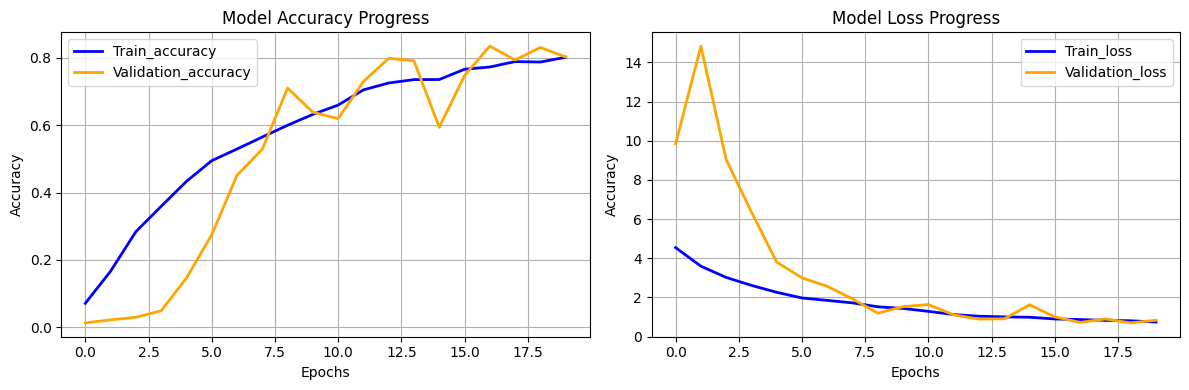

In [ ]:
from IPython.core.magics.osm import line_cell_magic
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Plot 1: Accuracy Evolution
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train_accuracy', color='blue', linewidth = 2)
plt.plot(history.history['val_accuracy'], label = 'Validation_accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot 2: Loss Evolution
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label= 'Train_loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation_loss', color='orange', linewidth=2)
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

import numpy as np
from sklearn.metrics import classification_report

# 1. Invert your mapping dictionary (turn Number -> Name)
# Since your original JSON has Name: Number, this flips it to Number: Name
id_to_medicine = {str(value): key for key, value in drug_map.items()}

# 2. Reset the test generator to ensure it starts from the very first image
test_generator.reset()

# 3. Get predictions (probabilities) from the model
predictions = model.predict(test_generator)

# 4. Convert probabilities to class indices (pick the highest percentage match)
predicted_classes = np.argmax(predictions, axis=1)

# 5. Get the true numeric labels from the generator
true_classes = test_generator.classes

# 6. Map the generator's class indices back to the actual medicine names
# Keras stores the classes as sorted strings, so we map them using our inverted dict
generator_classes = list(test_generator.class_indices.keys())
actual_medicine_names = [id_to_medicine.get(num, f"Unknown_{num}") for num in generator_classes]

# 7. Print the beautiful text evaluation report with actual drug names
print("--- Detailed Classification Report (Actual Medicine Names) ---")
print(classification_report(true_classes, predicted_classes, target_names=actual_medicine_names))

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
--- Detailed Classification Report (Actual Medicine Names) ---
              precision    recall  f1-score   support

       Aceta       0.69      0.90      0.78        10
         Ace       0.80      0.80      0.80        10
    Backtone       0.90      0.90      0.90        10
    Baclofen       1.00      1.00      1.00        10
      Baclon       1.00      0.90      0.95        10
      Bacmax       1.00      0.90      0.95        10
       Beklo       1.00      0.40      0.57        10
     Bicozin       0.64      0.70      0.67        10
    Canazole       0.73      0.80      0.76        10
    Candinil       0.90      0.90      0.90        10
    Cetisoft       0.82      0.90      0.86        10
       Conaz       0.83      1.00      0.91        10
     Alatrol       0.83      0.50      0.62        10
      Dancel       0.89      0.80      0.84        10
     Denixil       0.70      0.70      0.70        10
       Diflu       1.00      0.4

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


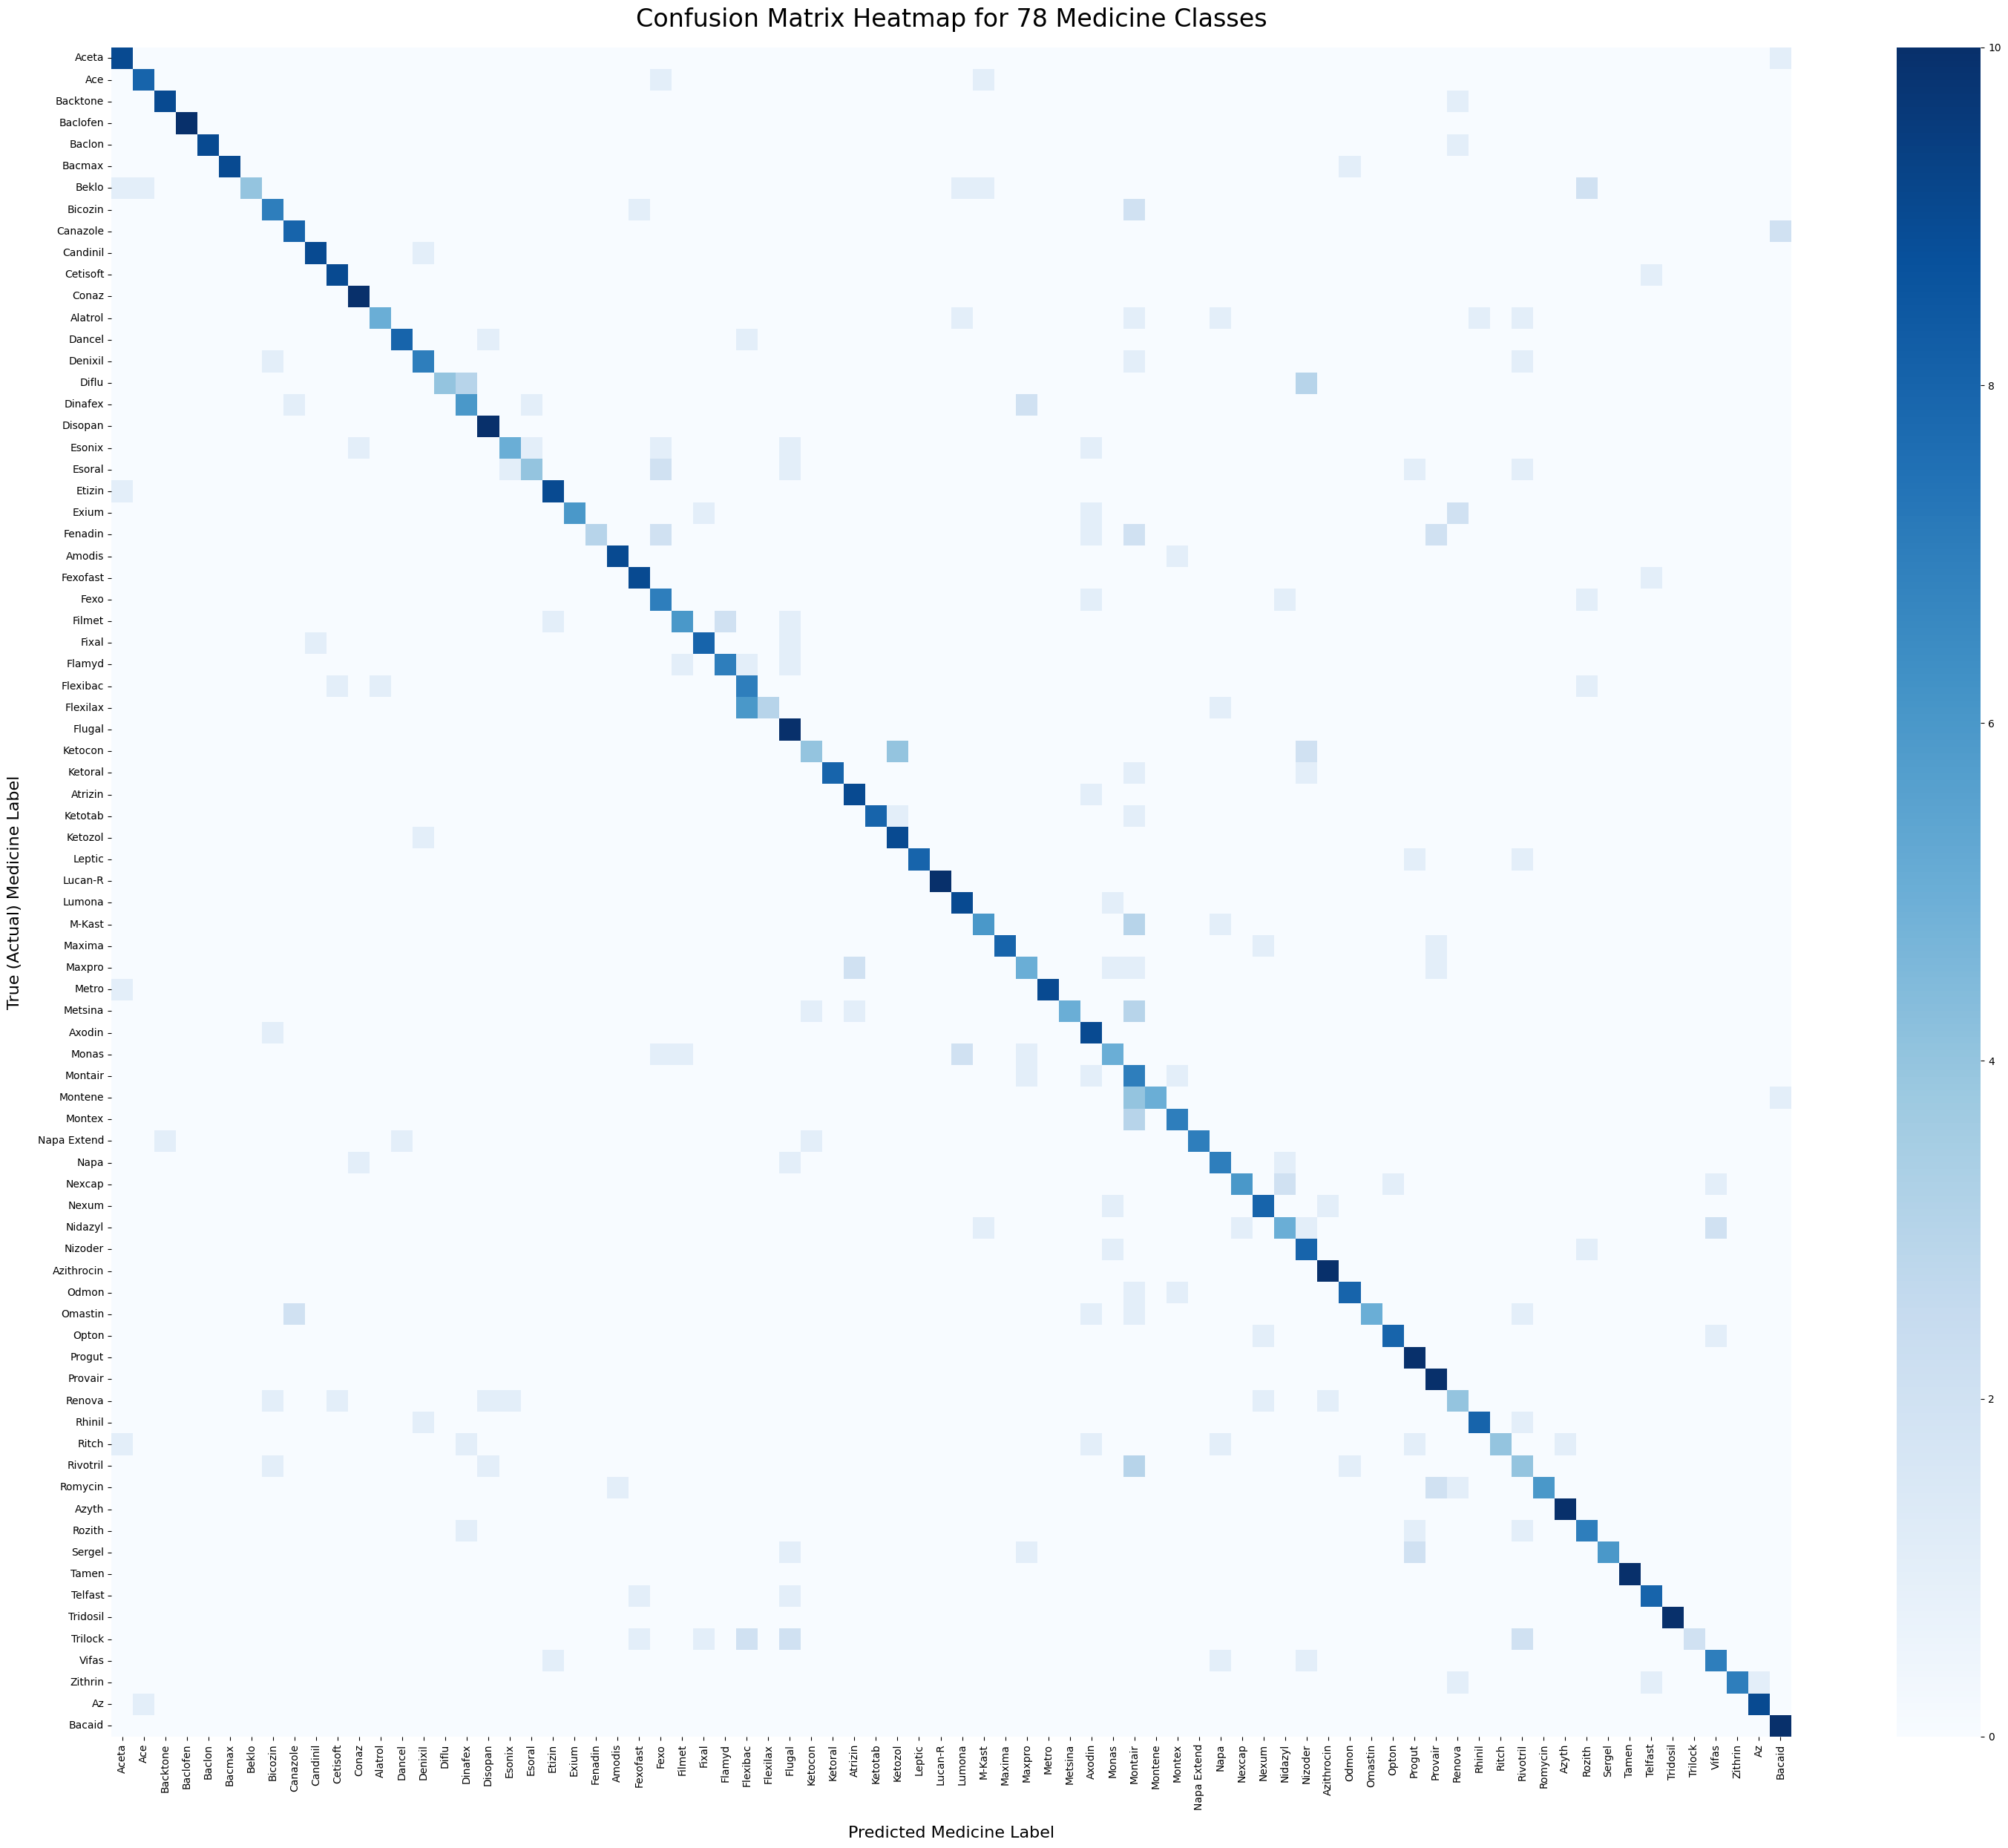

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Reset the test generator to ensure it starts from the first image
test_generator.reset()

# 2. Get predictions from the model
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# 3. Create the reverse dictionary to map Numbers back to Medicine Names
# (Assumes 'drug_map' is your original JSON dictionary with Name: Number)
id_to_medicine = {str(value): key for key, value in drug_map.items()}

# 4. Extract the actual text labels in the exact order Keras sorted them
generator_classes = list(test_generator.class_indices.keys())
actual_medicine_names = [id_to_medicine.get(num, f"Unknown_{num}") for num in generator_classes]

# 5. Compute the mathematical confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 6. Plot the massive 78x78 heatmap matrix
# We set a large figure size (30x25) so all 78 text labels are readable
plt.figure(figsize=(30, 25))
sns.heatmap(
    cm,
    annot=False,          # Turn off numbers inside boxes to avoid text overlapping
    cmap='Blues',         # Darker blue means more predictions landed there
    xticklabels=actual_medicine_names,
    yticklabels=actual_medicine_names
)

plt.title('Confusion Matrix Heatmap for 78 Medicine Classes', fontsize=24, pad=20)
plt.xlabel('Predicted Medicine Label', fontsize=16, labelpad=15)
plt.ylabel('True (Actual) Medicine Label', fontsize=16, labelpad=15)

# Rotate the axis labels so they don't overlap horizontally
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

# Save the matrix as a high-quality image file in Colab so you can download it for your report
plt.savefig('prescription_confusion_matrix.png', dpi=300)
plt.show()

Found 10 test images for drug: 'Telfast'


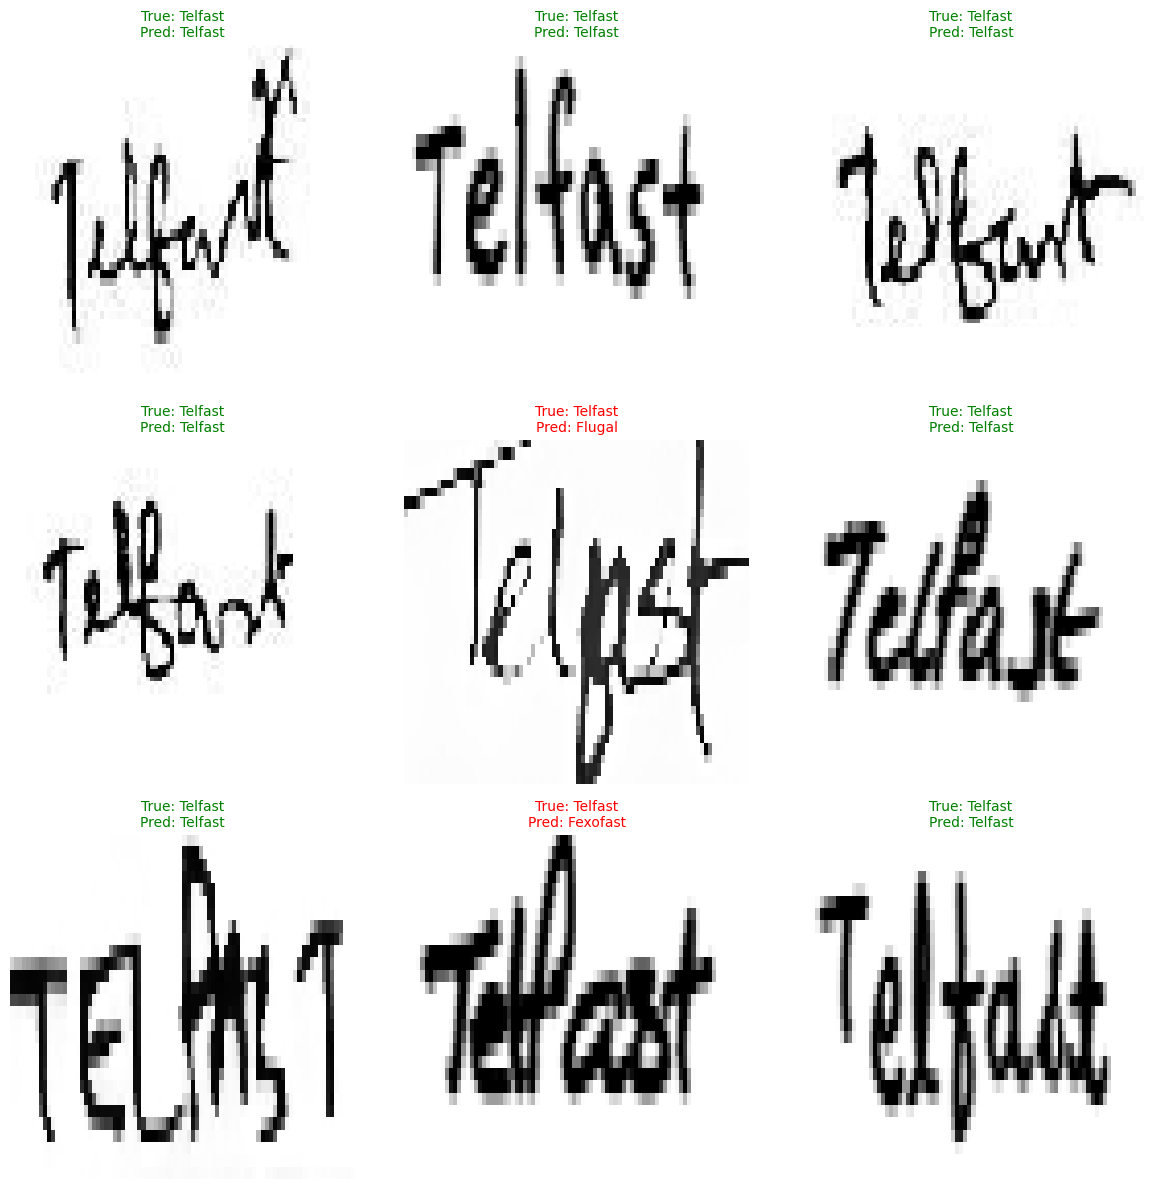

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# CHANGE THIS VARIABLE TO SEE DIFFERENT DRUGS
# Examples: 'Ace', 'Baclofen', 'Amoxicillin'
# ==========================================
TARGET_DRUG_NAME = "Telfast"

# 1. Create mapping dictionaries between your text names and JSON numbers
name_to_id = drug_map # Your original JSON dictionary (Name -> Number)
id_to_name = {str(value): key for key, value in drug_map.items()}

# 2. Get the unique string ID Keras assigned to this drug number
# Keras matches folder/CSV strings, so we look up the internal class indexing
keras_class_indices = test_generator.class_indices # Maps string number to internal index (0-77)

# Check if the drug exists in your JSON mapping
if TARGET_DRUG_NAME not in name_to_id:
    print(f"Error: '{TARGET_DRUG_NAME}' not found in your mapping.json file. Check spelling!")
else:
    drug_num_str = str(name_to_id[TARGET_DRUG_NAME])

    # 3. Find rows in your test CSV that match this specific drug name/number
    # (Change 'MEDICINE_NAME' to whatever your CSV column is called)
    matching_rows = test_df[test_df['MEDICINE_NAME'].astype(str) == drug_num_str]

    print(f"Found {len(matching_rows)} test images for drug: '{TARGET_DRUG_NAME}'")

    if len(matching_rows) == 0:
        print("No samples of this drug are present in the Test folder split.")
    else:
        # Limit to display a maximum of 9 images in a 3x3 grid
        num_to_display = min(9, len(matching_rows))

        plt.figure(figsize=(12, 12))

        # Loop through the matching rows and extract images
        for i in range(num_to_display):
            row = matching_rows.iloc[i]
            img_name = row['IMAGE'] # Your CSV image filename column

            # Construct absolute path to image
            img_path = os.path.join("/content/dataset/data/processed/test/images", img_name)

            # Read image in Grayscale (matching training conditions)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # 4. Preprocess image to match what the CNN expects
                img_resized = cv2.resize(img, (84, 84))
                img_normalized = img_resized / 255.0               # Scale pixels to [0,1]
                img_input = np.expand_dims(img_normalized, axis=-1) # Add channel dim -> (84, 84, 1)
                img_batch = np.expand_dims(img_input, axis=0)       # Add batch dim -> (1, 84, 84, 1)

                # 5. Make the Prediction
                pred_prob = model.predict(img_batch, verbose=0)
                pred_internal_idx = np.argmax(pred_prob, axis=1)[0]

                # Look up what text name matches the internal index Keras chose
                pred_num_str = [k for k, v in keras_class_indices.items() if v == pred_internal_idx][0]
                pred_drug_name = id_to_name.get(pred_num_str, f"Unknown_{pred_num_str}")

                # 6. Plot the results
                plt.subplot(3, 3, i + 1)
                plt.imshow(img_resized, cmap='gray')

                color = 'green' if pred_drug_name == TARGET_DRUG_NAME else 'red'
                plt.title(f"True: {TARGET_DRUG_NAME}\nPred: {pred_drug_name}", color=color, fontsize=10)
                plt.axis('off')
            else:
                print(f"Could not read image file: {img_path}")

        plt.tight_layout()
        plt.show()